# IQR Method for outlier detection
The Interquartile Range (IQR) method is a statistical technique used to identify outliers
in a dataset. It is based on the concept of quartiles, which divide the data into four equal parts. The IQR is calculated as the difference between the third quartile (Q3) and the first quartile (Q1):

```IQR = Q3 - Q1
```
To identify outliers using the IQR method, we can define the lower and upper bounds as follows:

```Lower Bound = Q1 - 1.5 * IQR
Upper Bound = Q3 + 1.5 * IQR
```
Any data points that fall below the lower bound or above the upper bound are considered outliers. This method is effective for detecting outliers in a dataset, especially when the data is not normally distributed.


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df=pd.read_csv('./placement (1).csv')

In [4]:
df.shape

(1000, 3)

<Axes: xlabel='placement_exam_marks', ylabel='Count'>

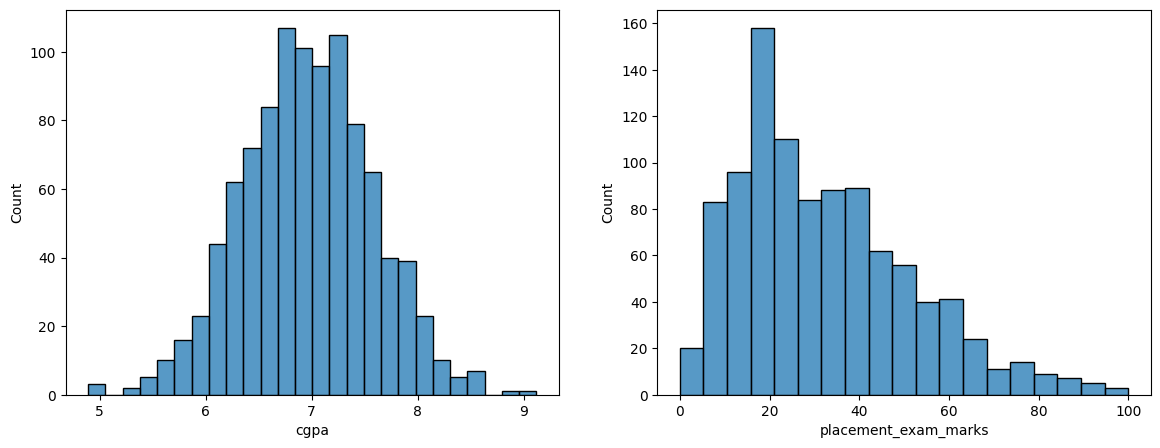

In [7]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'])
plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'])

In [8]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

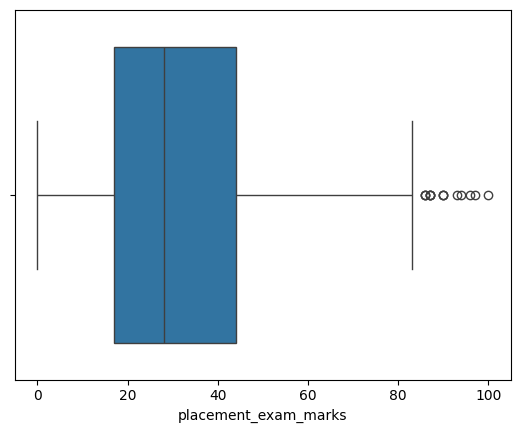

In [10]:
sns.boxplot(x=df['placement_exam_marks'])

In [17]:
# finding the IQR
Q1=np.percentile(df['placement_exam_marks'],25)
Q3=np.percentile(df['placement_exam_marks'],75)
IQR=Q3-Q1
print(IQR)

27.0


In [31]:
upperlimit=Q3+1.5*IQR
lowerlimit=Q1-1.5*IQR

In [32]:
df[df['placement_exam_marks']>upperlimit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [33]:
df[df['placement_exam_marks']<lowerlimit]

,cgpa,placement_exam_marks,placed


# trimming

In [34]:
new_df=df[(df['placement_exam_marks']<upperlimit)]

In [35]:
new_df.shape

(985, 3)

<Axes: xlabel='placement_exam_marks', ylabel='Count'>

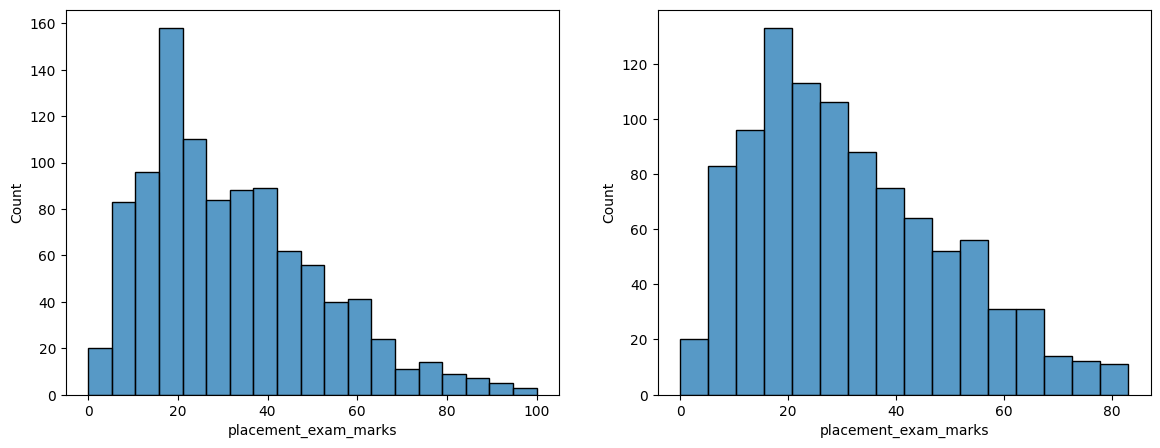

In [39]:
# Comparing the distribution of the original and new dataframes
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(df['placement_exam_marks'])
plt.subplot(1,2,2)
sns.histplot(new_df['placement_exam_marks'])

<Axes: xlabel='placement_exam_marks'>

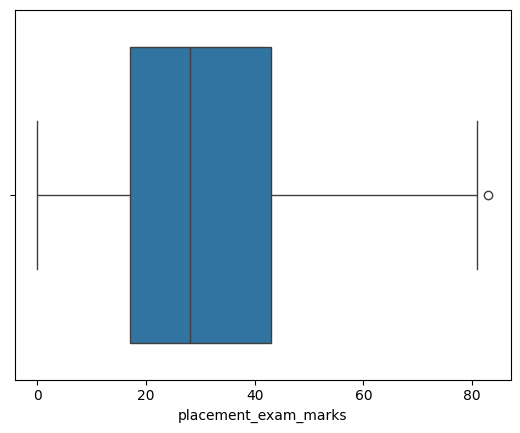

In [42]:

sns.boxplot(x=new_df['placement_exam_marks'])

In [43]:
# Capping
new_df2=df.copy()
new_df2['placement_exam_marks']=np.where(new_df2['placement_exam_marks']>upperlimit,upperlimit,new_df2['placement_exam_marks'])

In [44]:
new_df=df[(df['placement_exam_marks']<upperlimit) & (df['placement_exam_marks']>lowerlimit)]

In [45]:
new_df.shape

(985, 3)

<Axes: ylabel='placement_exam_marks'>

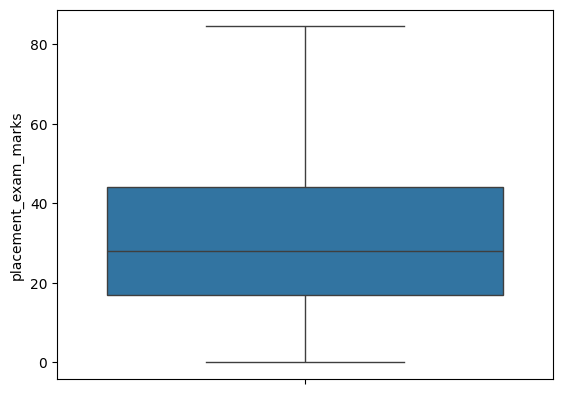

In [46]:
sns.boxplot(new_df2['placement_exam_marks'])